# A full Bayesian calibration of a local optical potential in about 30 seconds

In [1]:
import jitr

import rxmc

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


In [2]:
jitr.__version__

'2.6'

In [3]:
import lzma

import corner
import dill as pickle
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from tqdm import tqdm

## Define reaction

In [4]:
Ca40 = (40, 20)
n = (1, 0)
E_lab = 14.1

In [5]:
rxn = jitr.reactions.ElasticReaction(
    target=Ca40,
    projectile=n,
)
kinematics = rxn.kinematics(E_lab)

## Build a local optical potential

In [6]:
from jitr.optical_potentials.potential_forms import (
    thomas_safe,
    woods_saxon_prime_safe,
    woods_saxon_safe,
)


def central_potential(r, Vv, Wv, Rv, av, Wd, Rd, ad):
    return -(1j * Wv + Vv) * woods_saxon_safe(r, Rv, av) - (
        4j * ad * Wd
    ) * woods_saxon_prime_safe(r, Rd, ad)


# spin orbit interaction constant
mso = 1.0 / jitr.utils.constants.WAVENUMBER_PION


def spin_orbit_potential(r, Vso, Wso, Rso, aso):
    return (Vso + 1j * Wso) * mso**2 * thomas_safe(r, Rso, aso)

### Initial parameter guess for $^{40} \rm{Ca} (n,n)$

In [7]:
# This is the value of the parameters coming from the Koning-Delaroche parametrization.
# Taken from https://www-nds.iaea.org/RIPL-3/
VvKD = 46.7238
WvKD = 1.72334
WdKD = -7.2357
VsoKD = 6.1
WsoKD = -3.1

RvKD = 4.0538
RdKD = 4.4055
RsoKD = 1.01 * 40 ** (1.0 / 3.0)

avKD = 0.6718
adKD = 0.5379
asoKD = 0.60

alpha_central = np.array([VvKD, WvKD, RvKD, avKD, WdKD, RdKD, adKD])
alpha_so = np.array([VsoKD, WsoKD, RsoKD, asoKD])

len(alpha_central) + len(alpha_so)

11

## Experimental data for neutron scattering on $^{40}$ Ca

Let's consider the practical example of fitting an optical potential to a differential elastic scattering cross section measurement. In particular, we will use [this measurement](http://dx.doi.org/10.1016/0029-5582(64)90087-2) from 1964 by McDonald and Robson, available [here on Exfor](https://www-nds.iaea.org/exfor/servlet/X4sGetSubent?reqx=207&subID=11611003&plus=1).

In [8]:
from exfor_tools import ExforEntry

In [9]:
entry = ExforEntry(
    reaction=rxn,
    entry="11611",
    quantity="dXS/dA",
    vocal=True,
    filter_kwargs={"allow_cos": True},
)

Found subentry 11611003 with the following columns:
['EN', 'ANG-RSL', 'COS-CM', 'DATA-CM', 'DATA-ERR']


In [10]:
entry.meta

Authors:   W.J.Mcdonald, J.M.Robson
Title:     The Scattering Of 14.1 Mev Neutrons By Ca40.
Year:      1964
Institute: Univ. of Ottawa, Ottawa, Ontario
Reference: Nuclear Physics 59, 321 (1964); Private communication: Robson  (1967)
Subent:    11611001

In [11]:
m = entry.measurements[0]
m.y_units = "b/sr"

Text(0.5, 1.0, '$^{40} \\rm{Ca}(n,el)$\t EXFOR SUBENT: 11611003')

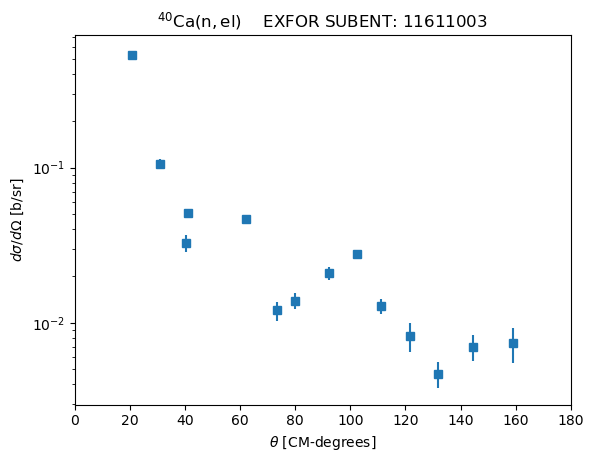

In [12]:
plt.errorbar(m.x, m.y, m.statistical_err, linestyle="none", marker="s")
plt.yscale("log")
plt.xlim([0, 180])
plt.xlabel(r"$\theta$ " + f"[{m.x_units}]")
plt.ylabel(r"$d \sigma / d \Omega$ " + f"[{m.y_units}]")
plt.title(f"${rxn.reaction_latex}$\t EXFOR SUBENT: {m.subentry}")

# Now let's do a calibration
Even though, as expected, the default values already do a great job.

## Specify prior

In [13]:
alpha_0 = np.hstack((alpha_central, alpha_so))
alpha_0

array([46.7238    ,  1.72334   ,  4.0538    ,  0.6718    , -7.2357    ,
        4.4055    ,  0.5379    ,  6.1       , -3.1       ,  3.45415141,
        0.6       ])

In [14]:
alpha_std = np.array([5, 2, 0.5, 0.1, 5, 0.5, 0.1, 2, 2, 0.1, 0.1])
alpha_std

array([5. , 2. , 0.5, 0.1, 5. , 0.5, 0.1, 2. , 2. , 0.1, 0.1])

In [15]:
prior = stats.multivariate_normal(mean=alpha_0, cov=np.diag((alpha_std) ** 2))

## Specifying the Model

In [16]:
from rxmc.params import Parameter

In [17]:
params = [
    Parameter("Vv", latex_name="$V_v$", unit="MeV"),
    Parameter("Wv", latex_name="$W_v$", unit="MeV"),
    Parameter("Rv", latex_name="$R_v$", unit="fm"),
    Parameter("av", latex_name="$a_v$", unit="fm"),
    Parameter("Wd", latex_name="$W_d$", unit="MeV"),
    Parameter("Rd", latex_name="$R_d$", unit="fm"),
    Parameter("ad", latex_name="$a_d$", unit="fm"),
    Parameter("Vso", latex_name="$V_{so}$", unit="MeV"),
    Parameter("Wso", latex_name="$W_{so}$", unit="MeV"),
    Parameter("Rso", latex_name="$R_{so}$", unit="fm"),
    Parameter("aso", latex_name="$a_{so}$", unit="fm"),
]
len(params)

11

In [18]:
def extract_params(ws, *x):
    Vv, Wv, Rv, av, Wd, Rd, ad, Vso, Wso, Rso, aso = x
    central_params = (Vv, Wv, Rv, av, Wd, Rd, ad)
    spin_orbit_params = (Vso, Wso, Rso, aso)
    return central_params, spin_orbit_params

In [19]:
omp = rxmc.elastic_diffxs_model.ElasticDifferentialXSModel(
    "dXS/dA",
    interaction_central=central_potential,
    interaction_spin_orbit=spin_orbit_potential,
    calculate_interaction_from_params=extract_params,
    params=params,
    model_name="KD_recalibration_Ca40nn",
)

## Set up `Observation`

In [20]:
obs = rxmc.elastic_diffxs_observation.ElasticDifferentialXSObservation(
    measurement=m,
    reaction=rxn,
    quantity="dXS/dA",
    lmax=40,
)

## Test out default values
They should do a good job to describe our observation already. We will use them as a prior mean, so if they describe our data well, that means we will start in a high-likelihood region and converge quickly.

In [21]:
yth = omp.visualizable_model_prediction(obs, *alpha_0)

Text(0.5, 1.0, '$^{40} \\rm{Ca}(n,el)$\t EXFOR SUBENT: 11611003')

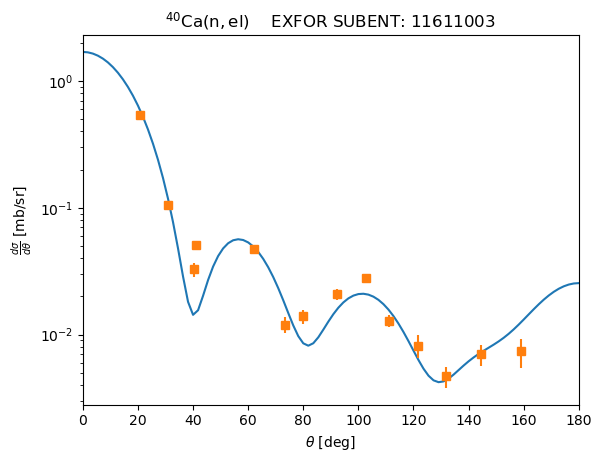

In [22]:
plt.plot(obs.angles_vis, yth)
plt.errorbar(m.x, m.y, m.statistical_err, linestyle="none", marker="s")
plt.yscale("log")
plt.xlim([0, 180])
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$\frac{d \sigma}{d \theta}$ [mb/sr]")
plt.title(f"${rxn.reaction_latex}$\t EXFOR SUBENT: {m.subentry}")

## Specify Likelihood Model and Evidence

We will set `fractional_uncorrelated_error` as a fraction of the model prediction whose square will be added to the diagonal elements of the covariance while calculating the likelihood. This is often interpreted as a "model error", or "unaccounted-for-error". A better strategy would be to fit this value (e.g. using `rxmc.likelihood_model.UnknownNoiseFractionErrorModel`).

In [23]:
likelihood = rxmc.likelihood_model.LikelihoodModel()

In [24]:
evidence = rxmc.evidence.Evidence(
    [
        rxmc.constraint.Constraint(
            [obs],
            omp,
            likelihood,
        )
    ]
)

In [25]:
rng = np.random.default_rng(42)

## Run adaptive Metropolis

In [26]:
walker_adaptive = rxmc.walker.Walker(
    model_sampler=rxmc.param_sampling.BatchedAdaptiveMetropolisSampler(
        params=omp.params,
        prior=prior,
        starting_location=prior.mean,
        initial_proposal_cov=prior.cov / 10,
    ),
    evidence=evidence,
    rng=rng,
)

## Run Bayesian Calibration

In [27]:
%%time
walker_adaptive.walk(n_steps=100000, burnin=1000, batch_size=500, verbose=False)

CPU times: user 2min, sys: 61.4 ms, total: 2min
Wall time: 2min


In [28]:
cut = 50000
num_samples = 10000

prior_samples = prior.rvs(num_samples)

nsteps, npar = walker_adaptive.model_sampler.chain.shape
chain_adaptive = walker_adaptive.model_sampler.chain[
    cut + np.random.choice(np.arange(nsteps - cut), num_samples), :
]

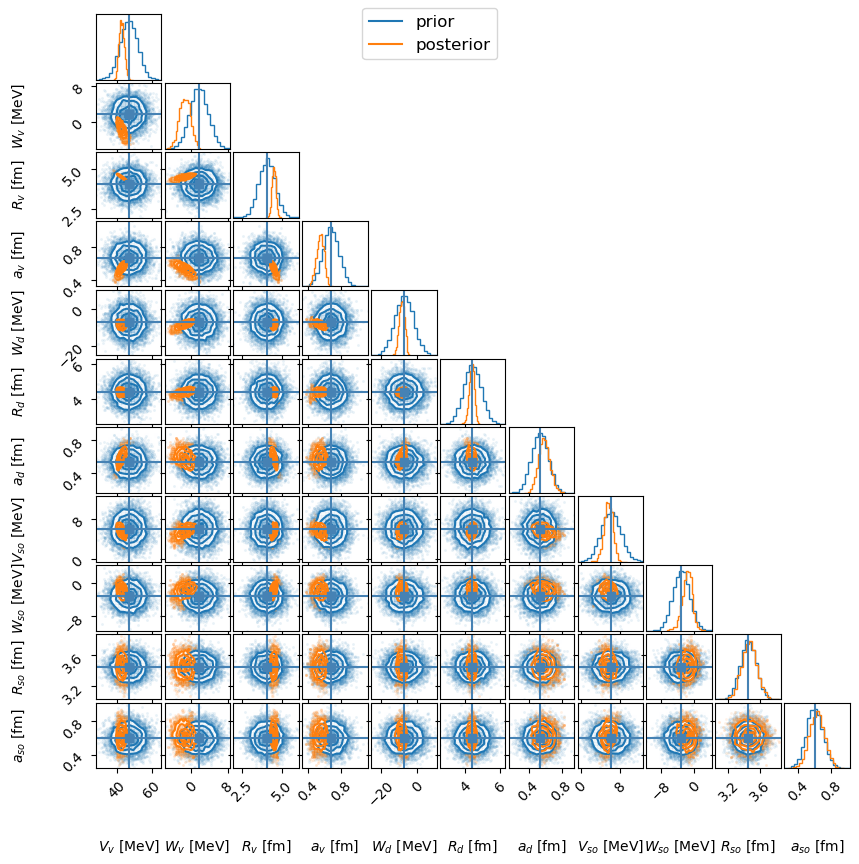

In [29]:
fig = plt.figure(figsize=(8, 8))
corner.corner(prior_samples, fig=fig, color="tab:blue")

corner.corner(
    chain_adaptive,
    labels=[f"{p.latex_name} [{p.unit}]" for p in omp.params],
    label_kwargs={"fontsize": 10},
    labelpad=0.75,
    max_n_ticks=2,
    label="posterior",
    truths=prior.mean,
    color="tab:orange",
    fig=fig,
)

plt.plot([], [], color="tab:blue", label="prior")
plt.plot([], [], color="tab:orange", label="posterior")
fig.legend(fontsize=12, loc="upper center")

In [30]:
num_samples = 10000

In [31]:
n_steps, _ = walker_adaptive.model_sampler.chain.shape
samples_adaptive = walker_adaptive.model_sampler.chain[
    cut + np.random.choice(np.arange(n_steps - cut), num_samples), :
]

In [32]:
# these are what we should end up with
np.testing.assert_allclose(
    np.mean(samples_adaptive, axis=0),
    [42.5, -1.40, 4.50, 0.54, -8.46, 4.38, 0.58, 5.40, -1.69, 3.46, 0.63],
    rtol=0.05,
)

## Calculate the $\chi^2/\text{DOF}$ distribution

In [33]:
y_pred_post = np.zeros((num_samples, len(obs.x)))
for i in tqdm(range(num_samples)):
    y_pred_post[i, :] = omp(obs, *samples_adaptive[i, :])

100%|██████████| 10000/10000 [00:08<00:00, 1214.58it/s]


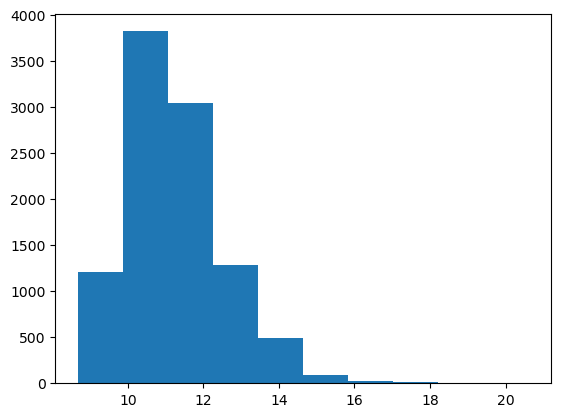

In [34]:
chi2 = np.sum(
    (y_pred_post - obs.y[np.newaxis, :]) ** 2 / obs.y_stat_err[np.newaxis, :] ** 2,
    axis=1,
)
num_dof = len(obs.x) - len(omp.params)

_ = plt.hist(chi2 / num_dof)

Notice the $\chi^2$/DOF is much greater than 1 for this simple model! It is worth thinking about what could be going on here. Are the experimentally reported statistical model errors too small? Is the model not flexible enough to describe the data well? 

Another useful check is looking as empirical coverage and predictive posteriors.

## Calculate predictive posteriors

## 

In [35]:
y_pred_post_vis = np.zeros((num_samples, len(obs.angles_vis)))
for i in tqdm(range(num_samples)):
    y_pred_post_vis[i, :] = omp.visualizable_model_prediction(
        obs, *samples_adaptive[i, :]
    )

100%|██████████| 10000/10000 [00:08<00:00, 1196.03it/s]


Text(0.5, 1.0, '$^{40} \\rm{Ca}(n,el)$ at 14.1 MeV')

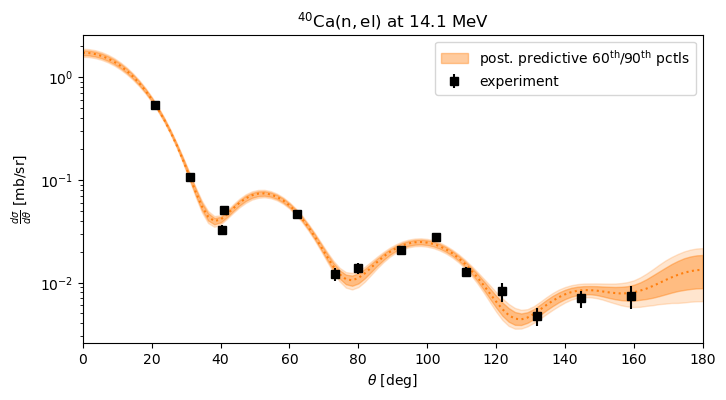

In [36]:
fig = plt.figure(figsize=(8, 4))
lower, med, upper = np.percentile(y_pred_post_vis, [5, 50, 95], axis=0)
posterior_color = "tab:orange"
plt.plot(obs.angles_vis, med, ":", color=posterior_color)
p = plt.fill_between(
    obs.angles_vis,
    lower,
    upper,
    alpha=0.2,
    color=posterior_color,
)
lower, upper = np.percentile(
    y_pred_post_vis,
    [16, 84],
    axis=0,
)
p = plt.fill_between(
    obs.angles_vis,
    lower,
    upper,
    alpha=0.4,
    color=posterior_color,
    label=r"post. predictive $60^{\text{th}}$/90$^{\text{th}}$ pctls",
)


plt.errorbar(
    m.x,
    m.y,
    m.statistical_err,
    linestyle="none",
    marker="s",
    label="experiment",
    color="k",
)
plt.yscale("log")
plt.xlim([0, 180])
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$\frac{d \sigma}{d \theta}$ [mb/sr]")
plt.legend()
plt.title(f"${rxn.reaction_latex}$ at {m.Einc} MeV")

## plot emprical coverage

In [37]:
pctl_bounds = np.arange(2, 100, 1)
assert pctl_bounds.shape[0] % 2 == 0

left = 0
right = len(pctl_bounds) - 1
inner = []
emp_cov = []
while left <= right:
    pctl_low, pctl_high = pctl_bounds[left], pctl_bounds[right]
    inner.append(pctl_high - pctl_low)
    ylow, yhigh = np.percentile(y_pred_post, [pctl_low, pctl_high], axis=0)
    emp_cov.append(
        np.sum(
            np.logical_and(
                obs.y - obs.y_stat_err / 2 >= ylow, obs.y + obs.y_stat_err / 2 < yhigh
            )
        )
        / obs.n_data_pts
    )
    left += 1
    right -= 1

Text(0, 0.5, 'empirical coverage [%]')

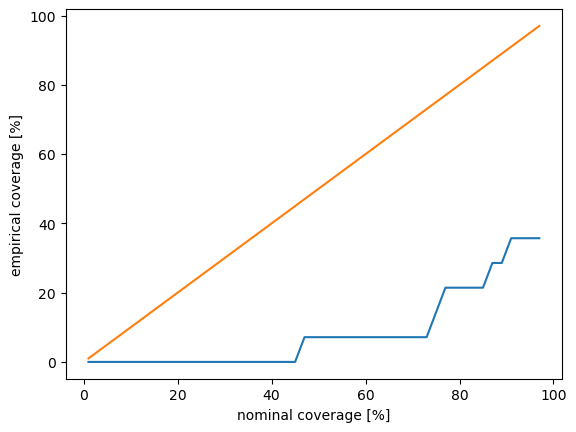

In [38]:
plt.plot(inner, np.array(emp_cov) * 100)
plt.plot(inner, inner, label="ideal")
plt.xlabel("nominal coverage [%]")
plt.ylabel("empirical coverage [%]")

From this we can see that the empirical coverage paints a slightly different from the $\chi^2$/DOF, but also unfavorable picture of this calibration!

Ideally, we would want the inner $N\%$ interval to contain $N\%$ of the experimental data (within experimental errors). 

In practice our model covers less of the experimental data than we would expect - a sign of overconfidence!